# Google Earth Engine Agent Demo

This notebook demonstrates the GAS `google_earth_engine_agent` using the GAS Client SDK. It shows each core skill:

- Compute NDVI summary from Sentinel-2 or Landsat
- Create daily NDVI time series with CSV and chart outputs
- Preview an NDVI map with Earth Engine thumbnail/map tile preview URLs
- Create durable GeoJSON/HTML map artifacts for downstream GAS workflows
- Preview a cloud-filtered median composite with Earth Engine visualization preview URLs
- Create climate/environmental variable time series with CSV and chart outputs
- Summarize land-cover class area from ESA WorldCover or Dynamic World
- Preview classified land-cover maps with Earth Engine thumbnail/map tile URLs
- Map surface-water occurrence or recent flood water with JRC Global Surface Water or Sentinel-1
- Create an Earth Engine export task after deciding a preview is useful
- Use an input vector dataset as the Earth Engine analysis region

The client need to provide an OpenAI API key. Earth Engine credentials are managed on the GAS server/deployment environment. 

See the agent profile in the GAS Store: https://www.geospatial-agentic-services.online/registry


In [ ]:
%pip install -q python-dotenv pandas requests
%pip install gas-client

In [ ]:
from pathlib import Path
import html
import json
import os
import sys

import pandas as pd
import requests
from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from gas_client import GasClient

## User Settings: Create a GAS Client by connecting to a GAS Server

In [ ]:
project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent

load_dotenv(project_root / ".env")

server_url = "https://www.geospatial-agentic-services.online/" #GIBD GAS Server URL - change if using a different server or local deployment.
agent_id = "google_earth_engine_agent"
data_retrieval_agent_id = "geospatial_data_retrieval_agent"

openai_api_key = os.getenv("OPENAI_API_KEY")

if openai_api_key:
    model_credentials = {"OPENAI_API_KEY": openai_api_key}
else:
    raise RuntimeError("Set OPENAI_API_KEY in the repo .env file before running this notebook.")

client = GasClient(
    server_url,
    default_credentials=model_credentials,
    artifact_delivery="URL",
    timeout=1800,
)
gee_agent = client.agent(agent_id)
data_agent = client.agent(data_retrieval_agent_id)

centre_county_bbox = [-78.376882,  40.691557, -77.143804,  41.252752]  # Used only for the optional vector-input example below.
server_url, agent_id, data_retrieval_agent_id

## Describe the Agent Capabilities

In [ ]:
description = gee_agent.describe(refresh=True)
display(Markdown(f"## {description['profile']['name']}"))
display(Markdown(description['profile']['description']))

pd.DataFrame(
    [
        {
            "skill_id": skill["skill_id"],
            "name": skill["name"],
            "description": skill["description"],
        }
        for skill in description["skills"]
    ]
)

## Supported GEE Parameters

The GEE agent is natural-language first: ordinary users should describe the task, place, dates, dataset preference, and desired outputs in the instructions. Parameters are optional controls for advanced or repeatable runs.

| Parameter | Use |
|---|---|
| `bbox` | Optional explicit bounding box `[min_lon, min_lat, max_lon, max_lat]`. Used when no vector input dataset is supplied; vector inputs override `bbox`, and `bbox` overrides place-name lookup. |
| `start_date`, `end_date` | Optional fallback dates in `YYYY-MM-DD` when the request text does not specify dates. |
| `max_cloud_percent` | Scene-level cloud threshold for Sentinel-2/Landsat filtering; useful values are often 10-30. |
| `scale` | Earth Engine reduction/export scale in meters; defaults to the selected dataset resolution. |
| `water_occurrence_threshold` | Optional JRC Global Surface Water occurrence percentage threshold. Defaults to 50. |
| `sentinel1_water_threshold_db` | Optional Sentinel-1 VV backscatter threshold in dB for recent water/flood screening. Defaults to -17. |
| `input_datasets` | Optional vector boundary artifact URLs or paths. If supplied, the first valid vector automatically becomes the analysis region for NDVI, composite, climate, land-cover, and export workflows. |
| `variables` | Optional climate/environmental variables for Skill 5, such as `precipitation`, `tmax`, `tmin`, `wind_speed`, `solar_radiation`, `pet`, `soil_moisture`, or `drought_index`. |
| `use_input_region` | Advanced opt-out switch. If `input_datasets` contains a valid vector, the agent uses it as the analysis region by default; set `False` only to ignore that vector and use `bbox` or text place lookup. |
| `export_destination` | Advanced override only. The server uses Google Cloud Storage automatically when `GEE_EXPORT_BUCKET` is configured. |
| `wait_timeout_seconds` | Advanced override only. Maximum seconds the export skill waits for Earth Engine completion or GCS object availability. |
| `poll_interval_seconds` | Advanced override only. Seconds between Earth Engine/GCS export status checks. |
| `signed_url_expiration_seconds` | Requested lifetime for a signed GCS HTTPS URL when the deployment can generate one. |
| `gcs_bucket` | Optional deployment-permitted bucket override; normally omit it. |
| `earth_engine_project` | Optional project override for deployments that allow it; normally omit it. |
| `requested_skill` | Advanced skill-selection hint; normally omit it and let the LLM plan from the request. |

## Skill 1: Compute NDVI Summary

This request asks the agent to plan and execute a Sentinel-2 NDVI summary over Centre County, Pennsylvania. The task is intentionally written in natural language and includes optional controls in the prompt; optional parameters for this skill include `max_cloud_percent`, `scale`, `start_date`, `end_date`, and `bbox`. Region priority is vector input first, then explicit `bbox`, then place-name lookup.

In [ ]:
ndvi_result = gee_agent.run_streaming_task(
    "Compute average NDVI for Centre County, Pennsylvania from Sentinel-2 surface reflectance from June 1 to June 30, 2024. "
    "Use max_cloud_percent 20, scale 30 meters. "
    "Return json summary artifacts with mean, min, max, and standard deviation.",
)

In [ ]:
# ndvi_result = gee_agent.run_streaming_task(
#     "Compute average NDVI for Centre County, Pennsylvania from Sentinel-2 surface reflectance from June 1 to June 30, 2024. "
#     "Use max_cloud_percent 20, scale 30 meters, and bbox [-78.37  40.69 -77.14  41.25]. "
#     "Return json summary artifacts with mean, min, max, and standard deviation.",
# )

In [ ]:
client.print_artifacts(ndvi_result)
client.display_artifacts(ndvi_result, format="json")
#client.get_artifacts(ndvi_result)
#client.get_artifact_urls(ndvi_result)
#print (ndvi_result)

## Retrieve the Geographic Boundary

This step uses the `geospatial_data_retrieval_agent` to retrieve a boundary for Centre County, Pennsylvania. The next NDVI time-series and map requests pass this returned vector artifact into the GEE agent through `input_datasets`; the GEE agent automatically uses the supplied vector as the analysis region.

In [60]:
boundary_result = data_agent.run_streaming_task(
    "Download the county boundary for Centre County, Pennsylvania only, as geojson.",
)


[14:31:26] stream_connected: Streaming connection established.
[14:31:26] Geospatial Data Retrieval Agent: I received your request.
[14:31:27] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[14:31:27] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[14:31:27] task_accepted: Task accepted. Starting streaming execution.
[14:31:28] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[14:31:28] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[14:31:29] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[14:31:29] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[14:31:29] Geospatial Data Retrieval Agent: I am comp

Artifacts: 1
1. Dataset
   role             : dataset_path
   format           : geojson
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-1939-kqsb-9085.geojson
   original_filename: download_the_619984.geojson
   size_bytes       : 15637
   url              : http://127.0.0.1:4042/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-1939-kqsb-9085.geojson


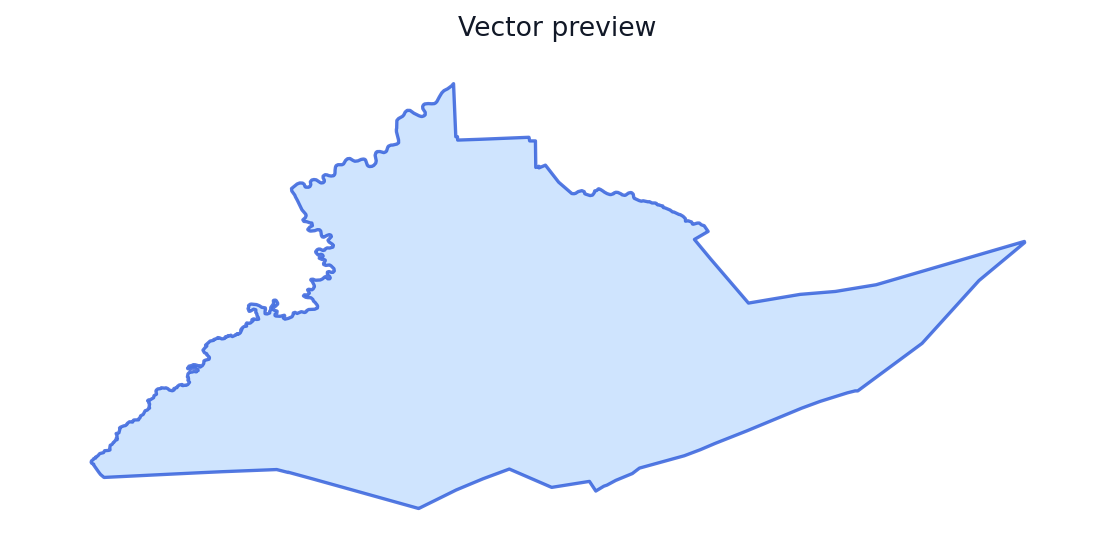

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
42,027,01214720,0500000US42027,42027,Centre,Centre County,PA,Pennsylvania,06,2871539708,11177389


In [61]:
client.print_artifacts(boundary_result)
client.display_artifacts(boundary_result, height=400)
boundary_url = client.get_artifact_urls(boundary_result)[0]

## Skill 2: Create Daily NDVI Time Series

This request asks the agent a time-series question: daily mean NDVI over the county boundary for the requested period. The agent creates one row per date with available imagery, and returns the requested HTML line chart. CSV and JSON report files are only returned when the request asks for those artifact formats; structured summary metadata is always available in the task response under `provenance["details"]["gee_summary"]`. Supported optional parameters include `max_cloud_percent`, `scale`, `bbox`, `start_date`, and `end_date`. When no vector input is supplied, explicit `bbox` overrides place-name lookup.

In [62]:
ndvi_timeseries_result = gee_agent.run_streaming_task(
    "Using the uploaded Centre County boundary, what is the daily NDVI from Sentinel-2 surface reflectance from June 1 to June 30, 2024? "
    "Return a professional HTML line chart of daily mean NDVI.",
    input_datasets=[boundary_url],
    parameters={"max_cloud_percent": 20, "scale": 30},
)

[14:32:29] stream_connected: Streaming connection established.
[14:32:29] Google Earth Engine Agent: I received your request.
[14:32:30] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:32:30] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:32:30] task_accepted: Task accepted. Starting streaming execution.
[14:32:31] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:32:31] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:32:35] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:32:35] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:32:35] Google Earth Engine Agent: I am executing the va

In [63]:
client.print_artifacts(ndvi_timeseries_result)
client.display_artifacts(ndvi_timeseries_result)

Artifacts: 1
1. Ndvi Time Series Html
   role             : ndvi_time_series_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-2821-ktcp-9800.html
   original_filename: gee_ndvi_time_series_using_the_uploaded_centre_county_753551.html
   size_bytes       : 1652
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-2821-ktcp-9800.html


## Skill 3: Create NDVI Map

This request asks the agent to create an actual NDVI raster preview using the retrieved county boundary as the Earth Engine analysis region. The preferred first map delivery is the Earth Engine thumbnail artifact/map tile preview URL. The HTML map displays the Earth Engine NDVI tile layer with the boundary overlay. For NDVI map previews, the agent relaxes scene-level cloud metadata filtering and applies per-pixel cloud/shadow/snow masking before compositing; this avoids dropping adjacent satellite tiles and showing only part of the region. Optional parameters shown here are `max_cloud_percent` and `scale`; the same skill also supports `bbox`, `start_date`, and `end_date`. When no vector input is supplied, explicit `bbox` overrides place-name lookup.

Expected artifacts: `ndvi_thumbnail_png_url` is the primary Earth Engine raster preview, `ndvi_map_summary_json_file` contains processing metadata and tile URLs, and `ndvi_interactive_map_html_file` is a local interactive map with the NDVI tile layer. The audited LLM/GEE plan is kept in the task response metadata under `provenance["details"]["validated_plan"]` for provenance and reproducibility, not as a main downloadable artifact.

In [64]:
ndvi_map_result = gee_agent.run_streaming_task(
    "Use the Centre County boundary as the analysis region. Create an NDVI map from Sentinel-2 surface reflectance from June 1 to June 30, 2024. "
    "Use max_cloud_percent 20 and scale 30 meters. "
    "Return an interactive HTML map with the NDVI raster tile layer.",
    input_datasets=[boundary_url],
)

[14:33:19] stream_connected: Streaming connection established.
[14:33:19] Google Earth Engine Agent: I received your request.
[14:33:19] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:33:19] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:33:19] task_accepted: Task accepted. Starting streaming execution.
[14:33:20] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:33:20] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:33:24] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:33:25] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:33:25] Google Earth Engine Agent: I am executing the va

In [65]:
client.print_artifacts(ndvi_map_result)

Artifacts: 1
1. Ndvi Interactive Map Html
   role             : ndvi_interactive_map_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-0873-kvlo-8277.html
   original_filename: gee_ndvi_map_use_the_centre_county_boundary_254873.html
   size_bytes       : 39669
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-0873-kvlo-8277.html


In [66]:
client.display_artifacts(ndvi_map_result)

## Skill 4: Create Cloud-Filtered Median Composite

This request creates composite metadata and asks Earth Engine for thumbnail/map tile preview URLs plus an HTML preview artifact that displays the thumbnail. If the preview looks useful, call the export skill to create a durable GeoTIFF. Composite previews use per-pixel cloud masking for full-region coverage, like the NDVI map skill. Supported optional parameters include `max_cloud_percent`, `scale`, `bbox`, `start_date`, and `end_date`. When no vector input is supplied, explicit `bbox` overrides place-name lookup. If a vector boundary is supplied through `input_datasets`, it becomes the analysis region automatically.

[14:34:12] stream_connected: Streaming connection established.
[14:34:12] Geospatial Data Retrieval Agent: I received your request.
[14:34:12] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[14:34:13] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[14:34:13] task_accepted: Task accepted. Starting streaming execution.
[14:34:14] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[14:34:14] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[14:34:15] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[14:34:15] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[14:34:15] Geospatial Data Retrieval Agent: I am comp

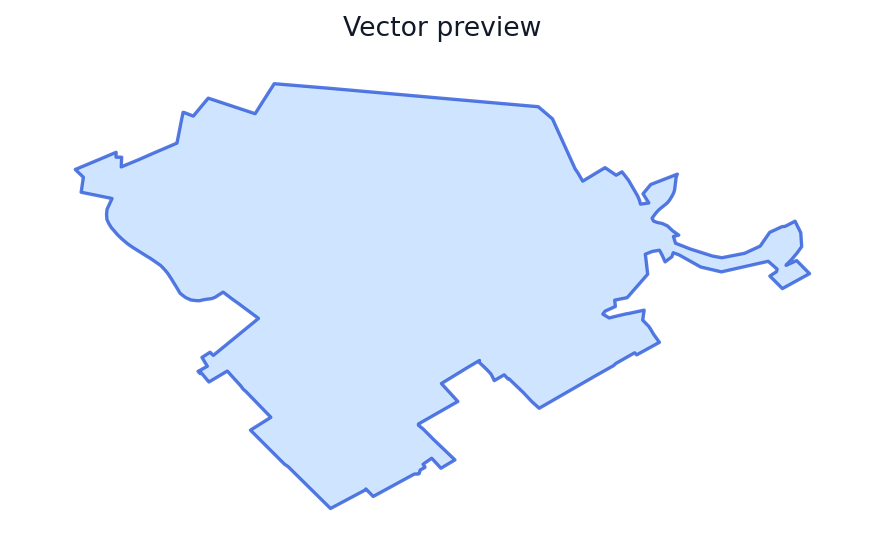

bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
-77.8861677,40.7683701,-77.8189976,40.8072297,349806674,relation,188627,40.7944504,-77.8616386,boundary,administrative,16,0.5640731584779716,city,State College,"State College, Centre County, Pennsylvania, United States"


In [67]:
#First call the data retrieval agent to get the boundary of State College, Pennsylvania, which is a borough within Centre County. Then pass that boundary as input to the GEE agent to compute NDVI and return an interactive map.
boundary_result = data_agent.run_streaming_task(
    "Download the boundary of State College, Pennsylvania.",
)
boundary_url = client.get_artifact_urls(boundary_result)[0]
client.display_artifacts(boundary_result, height=400)

In [68]:
composite_result = gee_agent.run_streaming_task(
    "Create a cloud-filtered median Sentinel-2 true-color composite for the provided boundary area "
    "from May 1 to May 30, 2026. Use max_cloud_percent 20 and scale 10 meters as optional controls. "
    "Return an interactive HTML map and a static image.",
    input_datasets=[boundary_url],
)

[14:34:28] stream_connected: Streaming connection established.
[14:34:28] Google Earth Engine Agent: I received your request.
[14:34:28] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:34:28] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:34:29] task_accepted: Task accepted. Starting streaming execution.
[14:34:30] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:34:30] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:34:34] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:34:34] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:34:34] Google Earth Engine Agent: I am executing the va

In [69]:
client.print_artifacts(composite_result)
client.display_artifacts(composite_result,format="html")

Artifacts: 2
1. Earth Engine Composite Preview
   role             : composite_thumbnail_png_url
   format           : png
   type             : downloadable_file
   name             : gee_composite_thumbnail.png
   original_filename: gee_composite_thumbnail.png
   url              : https://earthengine.googleapis.com/v1/projects/geospatialagenticservice/thumbnails/dd16847f5b45b4f0e481d97c3a1e8db7-b1cfa0273e032ced56765a929df14f96:getPixels
2. Cloud Filtered Composite Preview Html
   role             : cloud_filtered_composite_preview_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-6300-hvvy-2194.html
   original_filename: gee_cloud_filtered_composite_create_a_cloud_filtered_median_532280.html
   size_bytes       : 13602
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-6300-hvvy-2194.html


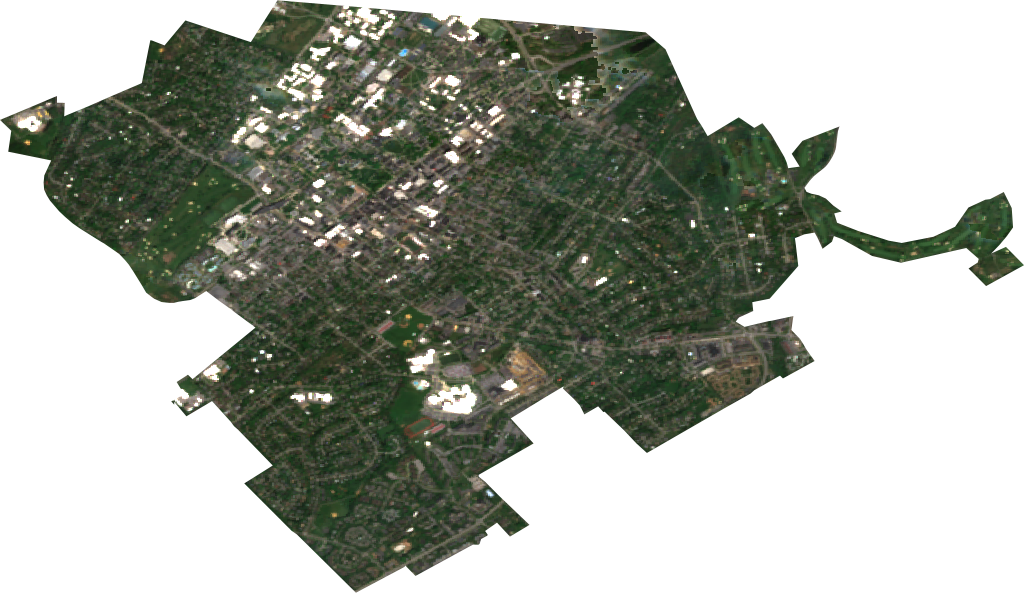

In [70]:
client.display_artifacts(composite_result,format="png")

## Skill 5: Create Climate Variable Time Series

This request creates a daily climate time series over the retrieved county boundary. The agent can select from CHIRPS, GRIDMET, Daymet, ERA5-Land, or TerraClimate based on requested variables, geography, and temporal resolution. Supported optional parameters include `variables`, `scale`, `bbox`, `start_date`, and `end_date`. Region priority is vector input first, then explicit `bbox`, then place-name lookup.

In [71]:
precip_result = gee_agent.run_streaming_task(
    "Create a daily climate time series for Centre County, Pennsylvania from July 1 to July 31, 2024. "
    "Use variables precipitation, tmax, tmin, wind_speed, and solar_radiation, with scale 4000 meters. "
    "Return a CSV table and an HTML line chart.",
    input_datasets=[boundary_url],
)


[14:35:30] stream_connected: Streaming connection established.
[14:35:30] Google Earth Engine Agent: I received your request.
[14:35:30] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:35:30] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:35:30] task_accepted: Task accepted. Starting streaming execution.
[14:35:32] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:35:32] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:35:36] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:35:37] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:35:37] Google Earth Engine Agent: I am executing the va

In [72]:
client.get_artifact_urls(precip_result)
#client.get_artifact_urls(precip_result, format="csv")
client.get_artifact_urls(precip_result, format="csv")

['http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-7366-lavi-4273.csv']

In [73]:
client.print_artifacts(precip_result)

Artifacts: 2
1. Climate Time Series Csv
   role             : climate_time_series_csv_file
   format           : csv
   type             : downloadable_file
   name             : google_earth_engine_agent-7366-lavi-4273.csv
   original_filename: gee_climate_time_series_create_a_daily_climate_time_230589.csv
   size_bytes       : 2860
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-7366-lavi-4273.csv
2. Climate Time Series Html
   role             : climate_time_series_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-1059-ozmy-1015.html
   original_filename: gee_climate_time_series_create_a_daily_climate_time_859077.html
   size_bytes       : 4933
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-1059-ozmy-1015.html


In [74]:
client.display_artifacts(precip_result)
#client.display_artifacts(precip_result, format="html")

date,precipitation,solar_radiation,tmax,tmin,wind_speed
2024-07-01,0.0,317.4991843710141,24.023871472417113,11.131224589445253,5.145305983874264
2024-07-02,0.0,319.20530557437826,27.172860157246532,15.704285913584215,3.0991835788804662
2024-07-03,0.0,177.28938966089368,29.539382872289593,20.930816774952234,5.343673614579806
2024-07-04,4.8697958031479205,225.1040815703723,31.49693105269455,21.40265652403542,2.700000047683716
2024-07-05,0.0,242.6820447649275,30.76918372329402,22.104284169722632,2.445306174609126


## Skill 6: Summarize and Map Land Cover

These requests demonstrate both land-cover table and map outputs. The first request computes class areas in square kilometers from ESA WorldCover. The second request asks for a classified map preview over the same uploaded boundary. Supported optional parameters include `scale`, `bbox`, `start_date`, and `end_date`; the request text can also ask for Dynamic World instead of ESA WorldCover. Region priority is vector input first, then explicit `bbox`, then place-name lookup.

In [75]:
land_cover_result = gee_agent.run_streaming_task(
    "Summarize ESA WorldCover land-cover class area for Centre County, Pennsylvania. "
    "Use scale 30 meters, start_date 2021-01-01, end_date 2021-12-31. "
    "Return a CSV table with class id, class name, and area in square kilometers.",
)

[14:36:24] stream_connected: Streaming connection established.
[14:36:25] Google Earth Engine Agent: I received your request.
[14:36:25] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[14:36:25] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:36:25] task_accepted: Task accepted. Starting streaming execution.
[14:36:26] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:36:26] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:36:31] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:36:32] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:36:32] Google Earth Engine Agent: I am executing the va

In [76]:
client.print_artifacts(land_cover_result)

Artifacts: 1
1. Land Cover Area Summary Csv
   role             : land_cover_area_summary_csv_file
   format           : csv
   type             : downloadable_file
   name             : google_earth_engine_agent-8207-uwuj-4954.csv
   original_filename: gee_land_cover_area_summary_summarize_esa_worldcover_land_cover_366410.csv
   size_bytes       : 291
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-8207-uwuj-4954.csv


In [77]:
client.display_artifacts(land_cover_result)

area_sq_km,class_id,class_name
5989.015149030115,10,Tree cover
648.4111994460933,30,Grassland
476.0954548481072,40,Cropland
79.99470681251782,50,Built-up
8.669470025782925,60,Bare/sparse vegetation


In [78]:
land_cover_map_result = gee_agent.run_streaming_task(
    "Create an ESA WorldCover land-cover map for Centre County, Pennsylvania using the uploaded county boundary. "
    "Use scale 30 meters and the 2021 ESA WorldCover layer. "
    "Return an interactive HTML map and the class-color legend.",
    input_datasets=[boundary_url],
    parameters={"scale": 30},
)


[14:36:50] stream_connected: Streaming connection established.
[14:36:50] Google Earth Engine Agent: I received your request.
[14:36:50] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:36:50] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:36:50] task_accepted: Task accepted. Starting streaming execution.
[14:36:51] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:36:51] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:36:56] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:36:57] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:36:57] Google Earth Engine Agent: I am executing the va

In [79]:
client.print_artifacts(land_cover_map_result)

Artifacts: 1
1. Land Cover Interactive Map Html
   role             : land_cover_interactive_map_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-2573-fhyx-6735.html
   original_filename: gee_land_cover_map_create_an_esa_worldcover_land_172877.html
   size_bytes       : 14958
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-2573-fhyx-6735.html


In [80]:
client.display_artifacts(land_cover_map_result)

In [ ]:
#print(land_cover_map_result.get("provenance", {}).get("details", {}))

## Skill 7: Map Surface Water or Recent Flood Water

This section demonstrates the new GEE surface-water workflow. The first request maps long-term water occurrence with JRC Global Surface Water and returns an HTML map plus exposure-ready CSV/GeoJSON outputs. The second request demonstrates the Sentinel-1 radar path for recent flood-water style screening over an explicit Harris County bbox and date range.

Expected artifacts include `surface_water_interactive_map_html_file`, `surface_water_summary_csv_file`, `surface_water_polygons_geojson_file`, and, when requested, `surface_water_thumbnail_png_url`. The CSV contains mapped water area and method fields; the GeoJSON contains polygons derived from the thresholded water mask.

[14:37:22] stream_connected: Streaming connection established.
[14:37:22] Google Earth Engine Agent: I received your request.
[14:37:22] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[14:37:22] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:37:22] task_accepted: Task accepted. Starting streaming execution.
[14:37:23] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:37:23] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:37:28] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:37:29] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:37:29] Google Earth Engine Agent: I am executing the va

dataset,dataset_id,date_end,date_start,region_name,scale_m,water_area_sq_km,water_definition
jrc_global_surface_water,JRC/GSW1_4/GlobalSurfaceWater,,,"Centre County, Pennsylvania, USA",30,24.28904857640625,JRC occurrence >= 50.0 percent


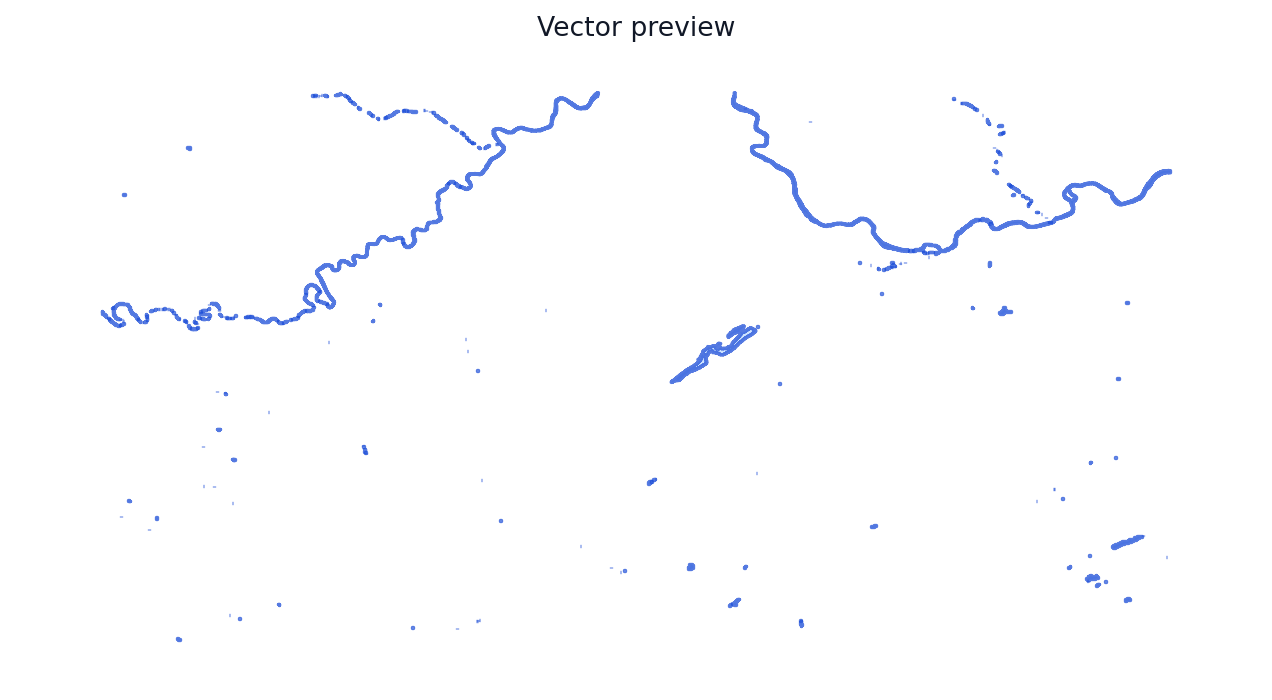

id,count,water_mask,region_name,dataset,water_class
+377170+159326,56,1,"Centre County, Pennsylvania, USA",jrc_global_surface_water,mapped_surface_water
+377180+159335,9,1,"Centre County, Pennsylvania, USA",jrc_global_surface_water,mapped_surface_water
+377183+160154,4,1,"Centre County, Pennsylvania, USA",jrc_global_surface_water,mapped_surface_water
+377197+159289,6,1,"Centre County, Pennsylvania, USA",jrc_global_surface_water,mapped_surface_water
+377222+159365,109,1,"Centre County, Pennsylvania, USA",jrc_global_surface_water,mapped_surface_water


In [81]:
surface_water_result = gee_agent.run_streaming_task(
    "Using Centre County, Pennsylvania as the analysis region, map surface water occurrence using JRC Global Surface Water. "
    "Return an interactive HTML map plus GeoJSON and CSV exposure-ready outputs with mapped water area.",
    parameters={"scale": 30, "water_occurrence_threshold": 50},
)
client.print_artifacts(surface_water_result)
client.display_artifacts(surface_water_result)


## Skill 8: Create an Earth Engine Export Task

This request starts an Earth Engine export task and returns export metadata. In the intended workflow, clients inspect an Earth Engine preview first, then call this export skill only when they need a durable GeoTIFF raster.

Earth Engine authentication, Cloud project selection, export permissions, and Google Cloud Storage configuration are handled by the GAS server deployment. Clients do not need to provide Earth Engine credentials or choose a storage bucket. When the server has `GEE_EXPORT_BUCKET` configured, Google Cloud Storage is selected automatically.

Supported optional task parameters include `scale`, `max_cloud_percent`, `bbox`, `start_date`, and `end_date`. Region priority is vector input first, then explicit `bbox`, then place-name lookup. Use GAS stream or async mode for long-running exports.

[14:38:14] stream_connected: Streaming connection established.
[14:38:14] Geospatial Data Retrieval Agent: I received your request.
[14:38:14] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[14:38:14] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[14:38:14] task_accepted: Task accepted. Starting streaming execution.
[14:38:15] Geospatial Data Retrieval Agent: Next I will start the workflow with the prepared inputs.
[14:38:15] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[14:38:16] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[14:38:16] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[14:38:16] Geospatial Data Retrieval Agent: I am comp

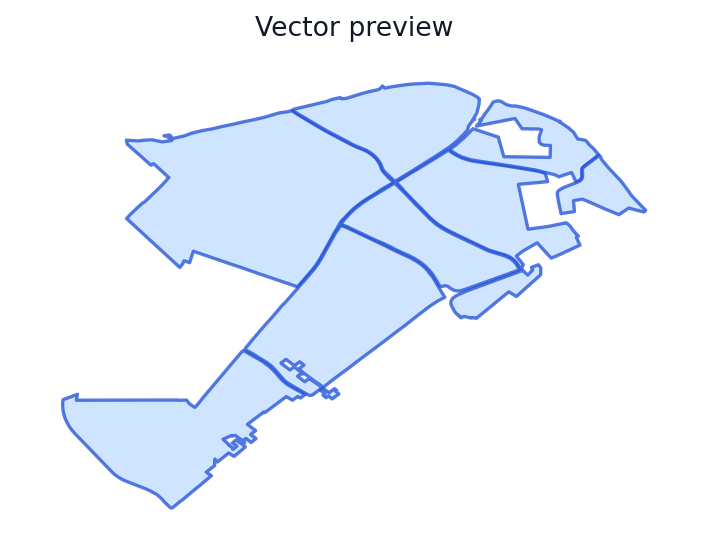

bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
-77.8918409,40.7798241,-77.8293611,40.8253481,349838666,relation,14073946,40.8128971,-77.8710571,amenity,university,30,0.6217236770535184,amenity,Penn State University,"Penn State University, 201, East Branch Road, Dalevue, Lemont, College Township, Centre County, Pennsylvania, 16802, United States"


In [82]:
boundary_result = data_agent.run_streaming_task(
    "Download the boundary of Penn State University.",
)
boundary_url = client.get_artifact_urls(boundary_result)[0]
client.display_artifacts(boundary_result, height=400)

In [83]:
export_result = gee_agent.run_streaming_task(
    "Create an Earth Engine Cloud Storage export task for a cloud-filtered Sentinel-2 median composite within the boundary "
    "from June 1 to June 30, 2024. ",
    input_datasets=[boundary_url],
 
)
client.print_artifacts(export_result)

[14:38:39] stream_connected: Streaming connection established.
[14:38:39] Google Earth Engine Agent: I received your request.
[14:38:40] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:38:40] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:38:40] task_accepted: Task accepted. Starting streaming execution.
[14:38:41] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:38:41] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:38:45] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:38:46] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:38:46] Google Earth Engine Agent: I am executing the va

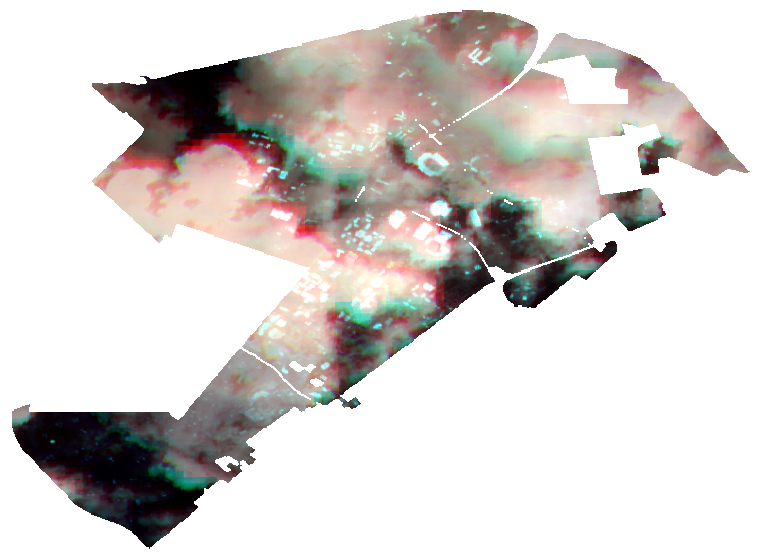

In [84]:
client.display_artifacts(export_result, format="tif")

In [85]:
client.display_artifacts(export_result, format="json")

## Skill 9: Use Vector Input as the Analysis Region

This section creates a small local GeoJSON polygon, sends it as an encoded GAS input dataset, and asks the GEE agent to use that vector geometry as the Earth Engine analysis region. This demonstrates a second vector-input pattern after the Census boundary retrieval workflow above. Supported optional parameters include `max_cloud_percent` and `scale`.

In [86]:
demo_region_path = project_root / "Data" / "gee_demo_centre_county_bbox.geojson"
demo_region_path.parent.mkdir(parents=True, exist_ok=True)
minx, miny, maxx, maxy = centre_county_bbox
demo_region = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"name": "Centre County demo bbox"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[
                    [minx, miny], [maxx, miny], [maxx, maxy], [minx, maxy], [minx, miny]
                ]],
            },
        }
    ],
}
demo_region_path.write_text(json.dumps(demo_region), encoding="utf-8")
encoded_region = client.encode_dataset_file(demo_region_path)
demo_region_path

WindowsPath('d:/GAS/Data/gee_demo_centre_county_bbox.geojson')

In [87]:
vector_region_result = gee_agent.run_streaming_task(
    "Use the uploaded vector polygon as the analysis region and create an NDVI map from Sentinel-2 from May 1 to May 30, 2026. "
    "Return an Earth Engine thumbnail preview and an interactive HTML map with the NDVI raster tile layer.",
    input_datasets=[encoded_region],
)
client.print_artifacts(vector_region_result)

[14:39:38] stream_connected: Streaming connection established.
[14:39:38] Google Earth Engine Agent: I received your request.
[14:39:38] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[14:39:38] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[14:39:38] task_accepted: Task accepted. Starting streaming execution.
[14:39:40] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[14:39:40] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[14:39:45] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[14:39:45] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[14:39:45] Google Earth Engine Agent: I am executing the va

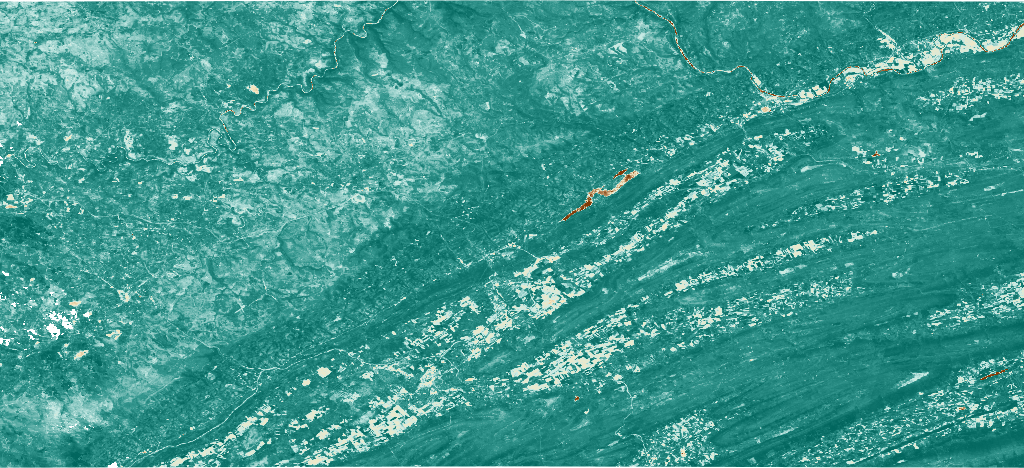

In [88]:
client.display_artifacts(vector_region_result)

## Inspect provenance information

Every run returns the provenance in the task response metadata. This makes the LLM planning step auditable and reproducible without mixing provenance JSON into the main downloadable artifacts.

In [89]:
vector_region_result["provenance"]["details"]["validated_plan"]


{'action': 'ndvi_map',
 'dataset': 'sentinel2_sr',
 'region': {'type': 'input_vector',
  'coordinates': [-78.376882, 40.691557, -77.143804, 41.252752],
  'name': 'gee_demo_centre_county_bbox.geojson',
  'geojson': {'type': 'Polygon',
   'coordinates': [[[-78.376882, 40.691557],
     [-77.143804, 40.691557],
     [-77.143804, 41.252752],
     [-78.376882, 41.252752],
     [-78.376882, 40.691557]]]}},
 'date_range': {'start': '2026-05-01', 'end': '2026-05-30'},
 'reducer': 'median',
 'scale': 10,
 'max_cloud_percent': 20.0,
 'outputs': ['html', 'tiles', 'thumbnail'],
 'export': {'enabled': False, 'destination': 'drive', 'description': ''},
 'variables': ['ndvi'],
 'source': 'llm_planned',
 'notes': ['Use uploaded vector polygon as analysis region (server priority).',
  'Compute NDVI from Sentinel-2 SR using a cloud-filtered median composite over the date range.',
  'Return an Earth Engine thumbnail preview (map) and an interactive HTML map with NDVI tile layer.']}

In [90]:
# Raw LLM plan before server validation
vector_region_result["provenance"]["details"]["raw_llm_plan"]

{'action': 'ndvi_map',
 'dataset': 'sentinel2_sr',
 'region': {'type': 'bbox',
  'coordinates': [-78.376882, 40.691557, -77.143804, 41.252752],
  'name': 'uploaded_vector_polygon (gee_demo_centre_county_bbox.geojson)'},
 'date_range': {'start': '2026-05-01', 'end': '2026-05-30'},
 'temporal_resolution': 'single_period',
 'reducer': 'median',
 'scale': 10,
 'cloud_filter': {'max_cloud_percent': 20},
 'variables': ['ndvi'],
 'outputs': ['map', 'html'],
 'export': {'enabled': False, 'destination': 'drive', 'description': ''},
 'notes': ['Use uploaded vector polygon as analysis region (server priority).',
  'Compute NDVI from Sentinel-2 SR using a cloud-filtered median composite over the date range.',
  'Return an Earth Engine thumbnail preview (map) and an interactive HTML map with NDVI tile layer.']}

In [91]:
# GEE processing summary / metadata
vector_region_result["provenance"]["details"]["gee_summary"]

{'action': 'ndvi_map',
 'dataset': 'sentinel2_sr',
 'dataset_id': 'COPERNICUS/S2_SR_HARMONIZED',
 'region': {'type': 'input_vector',
  'coordinates': [-78.376882, 40.691557, -77.143804, 41.252752],
  'name': 'gee_demo_centre_county_bbox.geojson',
  'geojson': {'type': 'Polygon',
   'coordinates': [[[-78.376882, 40.691557],
     [-77.143804, 40.691557],
     [-77.143804, 41.252752],
     [-78.376882, 41.252752],
     [-78.376882, 40.691557]]]}},
 'date_range': {'start': '2026-05-01', 'end': '2026-05-30'},
 'scale_m': 10,
 'visualization': {'min': -0.2,
  'max': 0.9,
  'palette': ['#7f3b08', '#f6e8c3', '#c7eae5', '#35978f', '#01665e']},
 'cloud_handling': {'scene_cloud_filter_percent': 100,
  'pixel_mask': 'Sentinel-2 SCL or Landsat QA_PIXEL cloud/shadow/snow mask before median compositing.',
  'reason': 'NDVI map previews prioritize full-region visual coverage; strict scene-level cloud metadata can drop adjacent Sentinel/Landsat tiles.',
  'requested_max_cloud_percent': 20.0},
 'preferr

In [92]:
from IPython.display import display

provenance = vector_region_result.get("provenance", {})
details = provenance.get("details", {})

display({
    "llm_calls": provenance.get("llm_calls"),
    "tool_calls": provenance.get("tool_calls"),
    "artifacts_created": provenance.get("artifacts_created"),
    "token_usage": provenance.get("token_usage"),
    "lineage": provenance.get("lineage"),
    "gee_summary": details.get("gee_summary"),
    "validated_plan": details.get("validated_plan"),
    "raw_llm_plan": details.get("raw_llm_plan"),
})

{'llm_calls': 1,
 'tool_calls': 6,
 'artifacts_created': 2,
 'token_usage': {'input_tokens': 1679,
  'output_tokens': 283,
  'total_tokens': 1962},
 'lineage': ['Used an LLM to create a constrained JSON Earth Engine workflow plan.',
  'Validated the plan against supported actions, datasets, region, date, scale, and output rules.',
  'Executed only trusted Google Earth Engine Python API tool functions.'],
 'gee_summary': {'action': 'ndvi_map',
  'dataset': 'sentinel2_sr',
  'dataset_id': 'COPERNICUS/S2_SR_HARMONIZED',
  'region': {'type': 'input_vector',
   'coordinates': [-78.376882, 40.691557, -77.143804, 41.252752],
   'name': 'gee_demo_centre_county_bbox.geojson',
   'geojson': {'type': 'Polygon',
    'coordinates': [[[-78.376882, 40.691557],
      [-77.143804, 40.691557],
      [-77.143804, 41.252752],
      [-78.376882, 41.252752],
      [-78.376882, 40.691557]]]}},
  'date_range': {'start': '2026-05-01', 'end': '2026-05-30'},
  'scale_m': 10,
  'visualization': {'min': -0.2,
   '